In [12]:
import cv2
import numpy as np

img = cv2.imread('car.png')
cv2.imshow('Car image',img) #'Car image' - заголовок окна, img - переменная, содержащая изображение

if img is not None:
    print(f"Ширина - {img.shape[0]} px, высота - {img.shape[1]} px, количество каналов: {img.shape[2]}")
    # print(f"Прочитано изображение размером {img.shape}")
else:
    print("Ошибка чтения изображения")

cv2.waitKey(0) #ожидает нажатия любой клавиши
cv2.destroyAllWindows() #закроет окно перед завершением скрипта


Ширина - 1024 px, высота - 1792 px, количество каналов: 3


In [13]:
import cv2
import numpy as np

# Загрузка исходного изображения
image = cv2.imread('car.png')

# Проверка, что изображение загружено
if image is None:
    print("Изображение не прочитано")
    exit()

red_channel = image[:, :, 2]  # Красный канал
green_channel = image[:, :, 1]  # Зеленый канал
blue_channel = image[:, :, 0]  # Синий канал

# Сохранение изображений
cv2.imwrite('red_channel.jpg', red_channel)
cv2.imwrite('green_channel.jpg', green_channel)
cv2.imwrite('blue_channel.jpg', blue_channel)

print("Images saved successfully.")

Images saved successfully.


Это зеленый круг


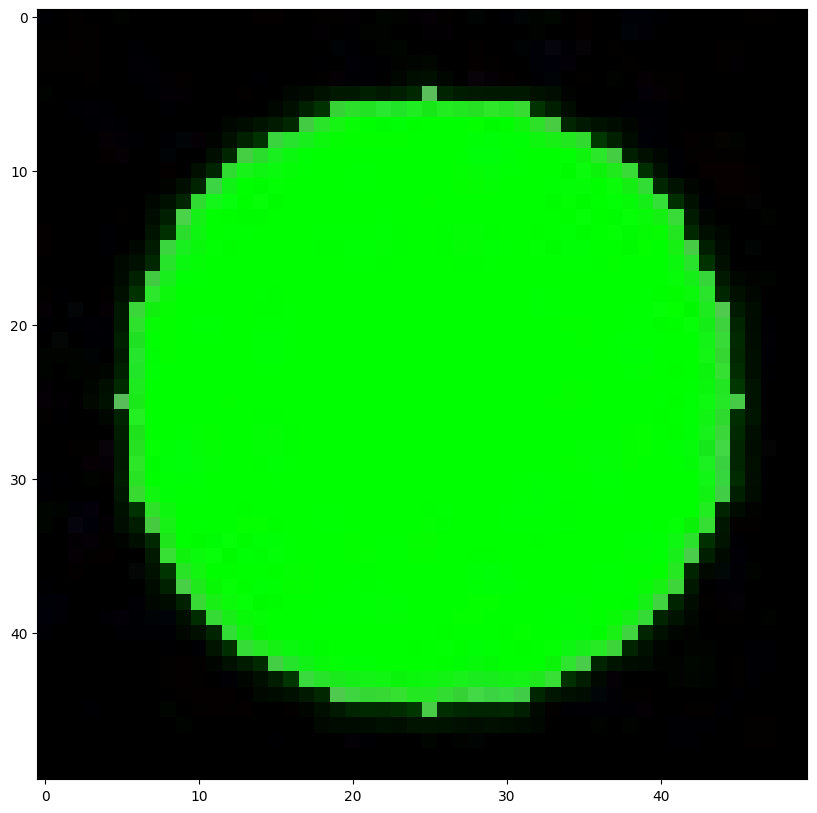

In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

image = cv2.imread("084.jpg")
pixels = np.sum(image)

image = (np.where(image<3,0,image))
image = (np.where(image>253,255,image))

color = tuple(image[25:26, 25:26][0][0])
# print(color)
colors = {(0, 255, 0): 'зеленый', 
        (255, 255, 255): 'белый',
        (255, 255, 0): 'голубой',
        (0, 0, 255): 'красный',
        (255, 0, 0): "синий",
        (255, 0, 255): "фиолетовый",
        (0, 255, 255): "желтый"
}
print(f"Это {colors[color]} ", end='')


# 5. Классификация фигуры
top = np.sum(image[10:11, 5:6], axis=2)
bot = np.sum(image[42:43, 5:6],axis=2)

if bot and top:
    print('квадрат')
elif bot and not top:
    print('треугольник')
elif not bot and not top:
    print('круг')

plt.figure(figsize=(10,10))
plt.imshow(image[...,::-1])




In [59]:
image

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[9, 0, 0],
        [5, 0, 0],
        [2, 0, 0],
        ...,
        [4, 0, 0],
        [2, 0, 0],
        [0, 0, 0]],

       [[4, 0, 0],
        [2, 0, 0],
        [0, 0, 0],
        ...,
        [2, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [ ]:
# image = cv2.imread('b.png')

# red_channel = image[:, :, 2]  # Красный канал
# green_channel = image[:, :, 1]  # Зеленый канал
# blue_channel = image[:, :, 0]  # Синий канал

# if red_channel.mean() > green_channel.mean() and red_channel.mean() > blue_channel.mean():
#     print('красный')

# if green_channel.mean() > red_channel.mean() and green_channel.mean() > blue_channel.mean():
#     print('зелёный')

# if blue_channel.mean() > green_channel.mean() and blue_channel.mean() > red_channel.mean():
#     print('синий')


# blue, green, red = np.sum(image[:, :, 0]), np.sum(image[:, :, 1]), np.sum(image[:, :, 2])
# print([['синий', 'зелёный'][max(blue, green, red) == green], 'красный'][max(blue, green, red) == red])
# print(red_channel)
# print(green_channel)
# print(blue_channel)

In [28]:

def detect_shape(image):
    # 1. Загрузка изображения и предобработка
    # image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 2. Бинаризация (фигура белая, фон черный)
    _, binary = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    
    
    # 3. Поиск контуров
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        # 4. Аппроксимация контура
        epsilon = 0.03 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        num_vertices = len(approx)
        
        # 5. Определение фигуры
        if num_vertices == 3:
            shape = "triangle"
        elif num_vertices == 4:
            # Проверка на квадрат/прямоугольник
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            if 0.9 <= aspect_ratio <= 1.1:
                shape = "square"
            else:
                shape = "rectangle"
        else:
            # Проверка на круг/эллипс
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0:
                perimeter = 1
            circularity = 4 * np.pi * area / (perimeter ** 2)
            if circularity > 0.8:
                shape = "circle"
            else:
                shape = "ellipse"
        
        # Вывод результата
        cv2.drawContours(image, [cnt], -1, (0, 255, 0), 2)
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            cv2.putText(image, shape, (cX - 20, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
    
    # Отображение результата
    cv2.imshow("Detected Shape", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return shape

# Пример использования
# image_path = "figure.png"  # Замените на путь к вашему изображению
detected_shape = detect_shape(image2)
print(f"Detected shape: {detected_shape}")
    
    

Detected shape: ellipse
